# Term Project 
## Milestone 1 - Rachel Wantuch - DSC 550
Dataset Source: https://www.kaggle.com/datasets/arushchillar/disneyland-reviews

Theme parks take in millions of visitors each year around the world. In order to serve them best companies want to know what they're thinking about their trip. One o the ways is fromr eviews on Trip Advisor. Theres also company sponsored surveys, social media, and word of mouth too.

This dataset I pulled from Kaggle covers reviews from 3 Disney theme parks that the user scraped from Trip Advisor. Its a fairly minimalistic dataset as far as columns go. I will be adding one more column to this though that has average weather temperature for that park's geographic location.

The goal of this project os to see if temperature affects sentiment based of the reviews and weather data. First I will have to run code to determine sentiment and that column will be added to the dataset. Next I will run logisitic regression to train my model to classify a review as positive or negative (potentially also neutral but that will be if I have time and with a different model). Finally I will run a simple linear regression model to see if there is a correlation between temperature and sentiment. It would also be interesting to see if sentiment correlated with the Rating column. Correlation doesn't equal causation but it could definitely play a part.

The first stages of this project will involve some EDA and graphing to see what the data looks like. Again, unfortunately due to it only having 6/7 columns its going to seem a little short here. If there are variables I can look for and add to the dataset I will but apart from weather I don't anticipate any late additions here.

I ran out of time to add the average monthly temp for each year into a column but that will be added so I can do the linear regression between temperatuer and sentiment.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import chardet

pd.reset_option('display.max_rows')
import warnings
warnings.filterwarnings('ignore')

In [4]:
#THis only needed to be ran once to find the encoding.
def detect_encoding(file_path):
        with open(file_path, 'rb') as f:
            raw_data = f.read()
            result = chardet.detect(raw_data)
            return result['encoding']
file_path="DisneylandReviews.csv"
    # Example usage:
file_encoding = detect_encoding(file_path)
print(f"Detected encoding: {file_encoding}")

Detected encoding: ISO-8859-1


In [13]:
df=pd.read_csv("DisneylandReviews.csv", encoding="ISO-8859-1")

In [14]:
df.head()

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong


In [15]:
df.shape

(42656, 6)

In [16]:
df.dtypes

Review_ID             int64
Rating                int64
Year_Month           object
Reviewer_Location    object
Review_Text          object
Branch               object
dtype: object

In [17]:
df['Year_Month'].value_counts()

Year_Month
missing    2613
2015-8      786
2015-7      759
2015-12     701
2015-6      692
           ... 
2010-8        7
2010-5        4
2019-5        2
2010-3        2
2010-4        1
Name: count, Length: 112, dtype: int64

I need to get rid of the 2613 occurances of 'missing'. There is no way to justify any means of imputing a form of data here that would make sense.

In [18]:
value='missing'
df=df[df.Year_Month != value]

## Preliminary Light Cleaning and EDA of the data

In [19]:
df.describe(include=['O'])

,Year_Month,Reviewer_Location,Review_Text,Branch
count,40043,40043,40043,40043
unique,111,162,40022,3
top,2015-8,United States,Hong Kong Disneyland is a very clean and lovel...,Disneyland_California
freq,786,13522,2,18202


It looks like we have some missing data in the Year_month column. I will remove the rows with missing values there. We can see 3 parks have reviews and the reviews come from 162 nations.

### Splitting the Year_Month Column into two new columns

In [20]:
df[['Year','Month']]=df['Year_Month'].str.split('-',expand=True)
df.head()

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,Year,Month
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,2019,4
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,2019,5
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,2019,4
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,2019,4
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,2019,4


## Graphs
### Bar Chart

In [21]:
values=df['Reviewer_Location'].value_counts()
cat=values.index
freq=values.values
print(values)

Reviewer_Location
United States     13522
United Kingdom     9115
Australia          4412
Canada             2116
India              1470
                  ...  
Madagascar            1
El Salvador           1
Sudan                 1
Åland Islands         1
Andorra               1
Name: count, Length: 162, dtype: int64


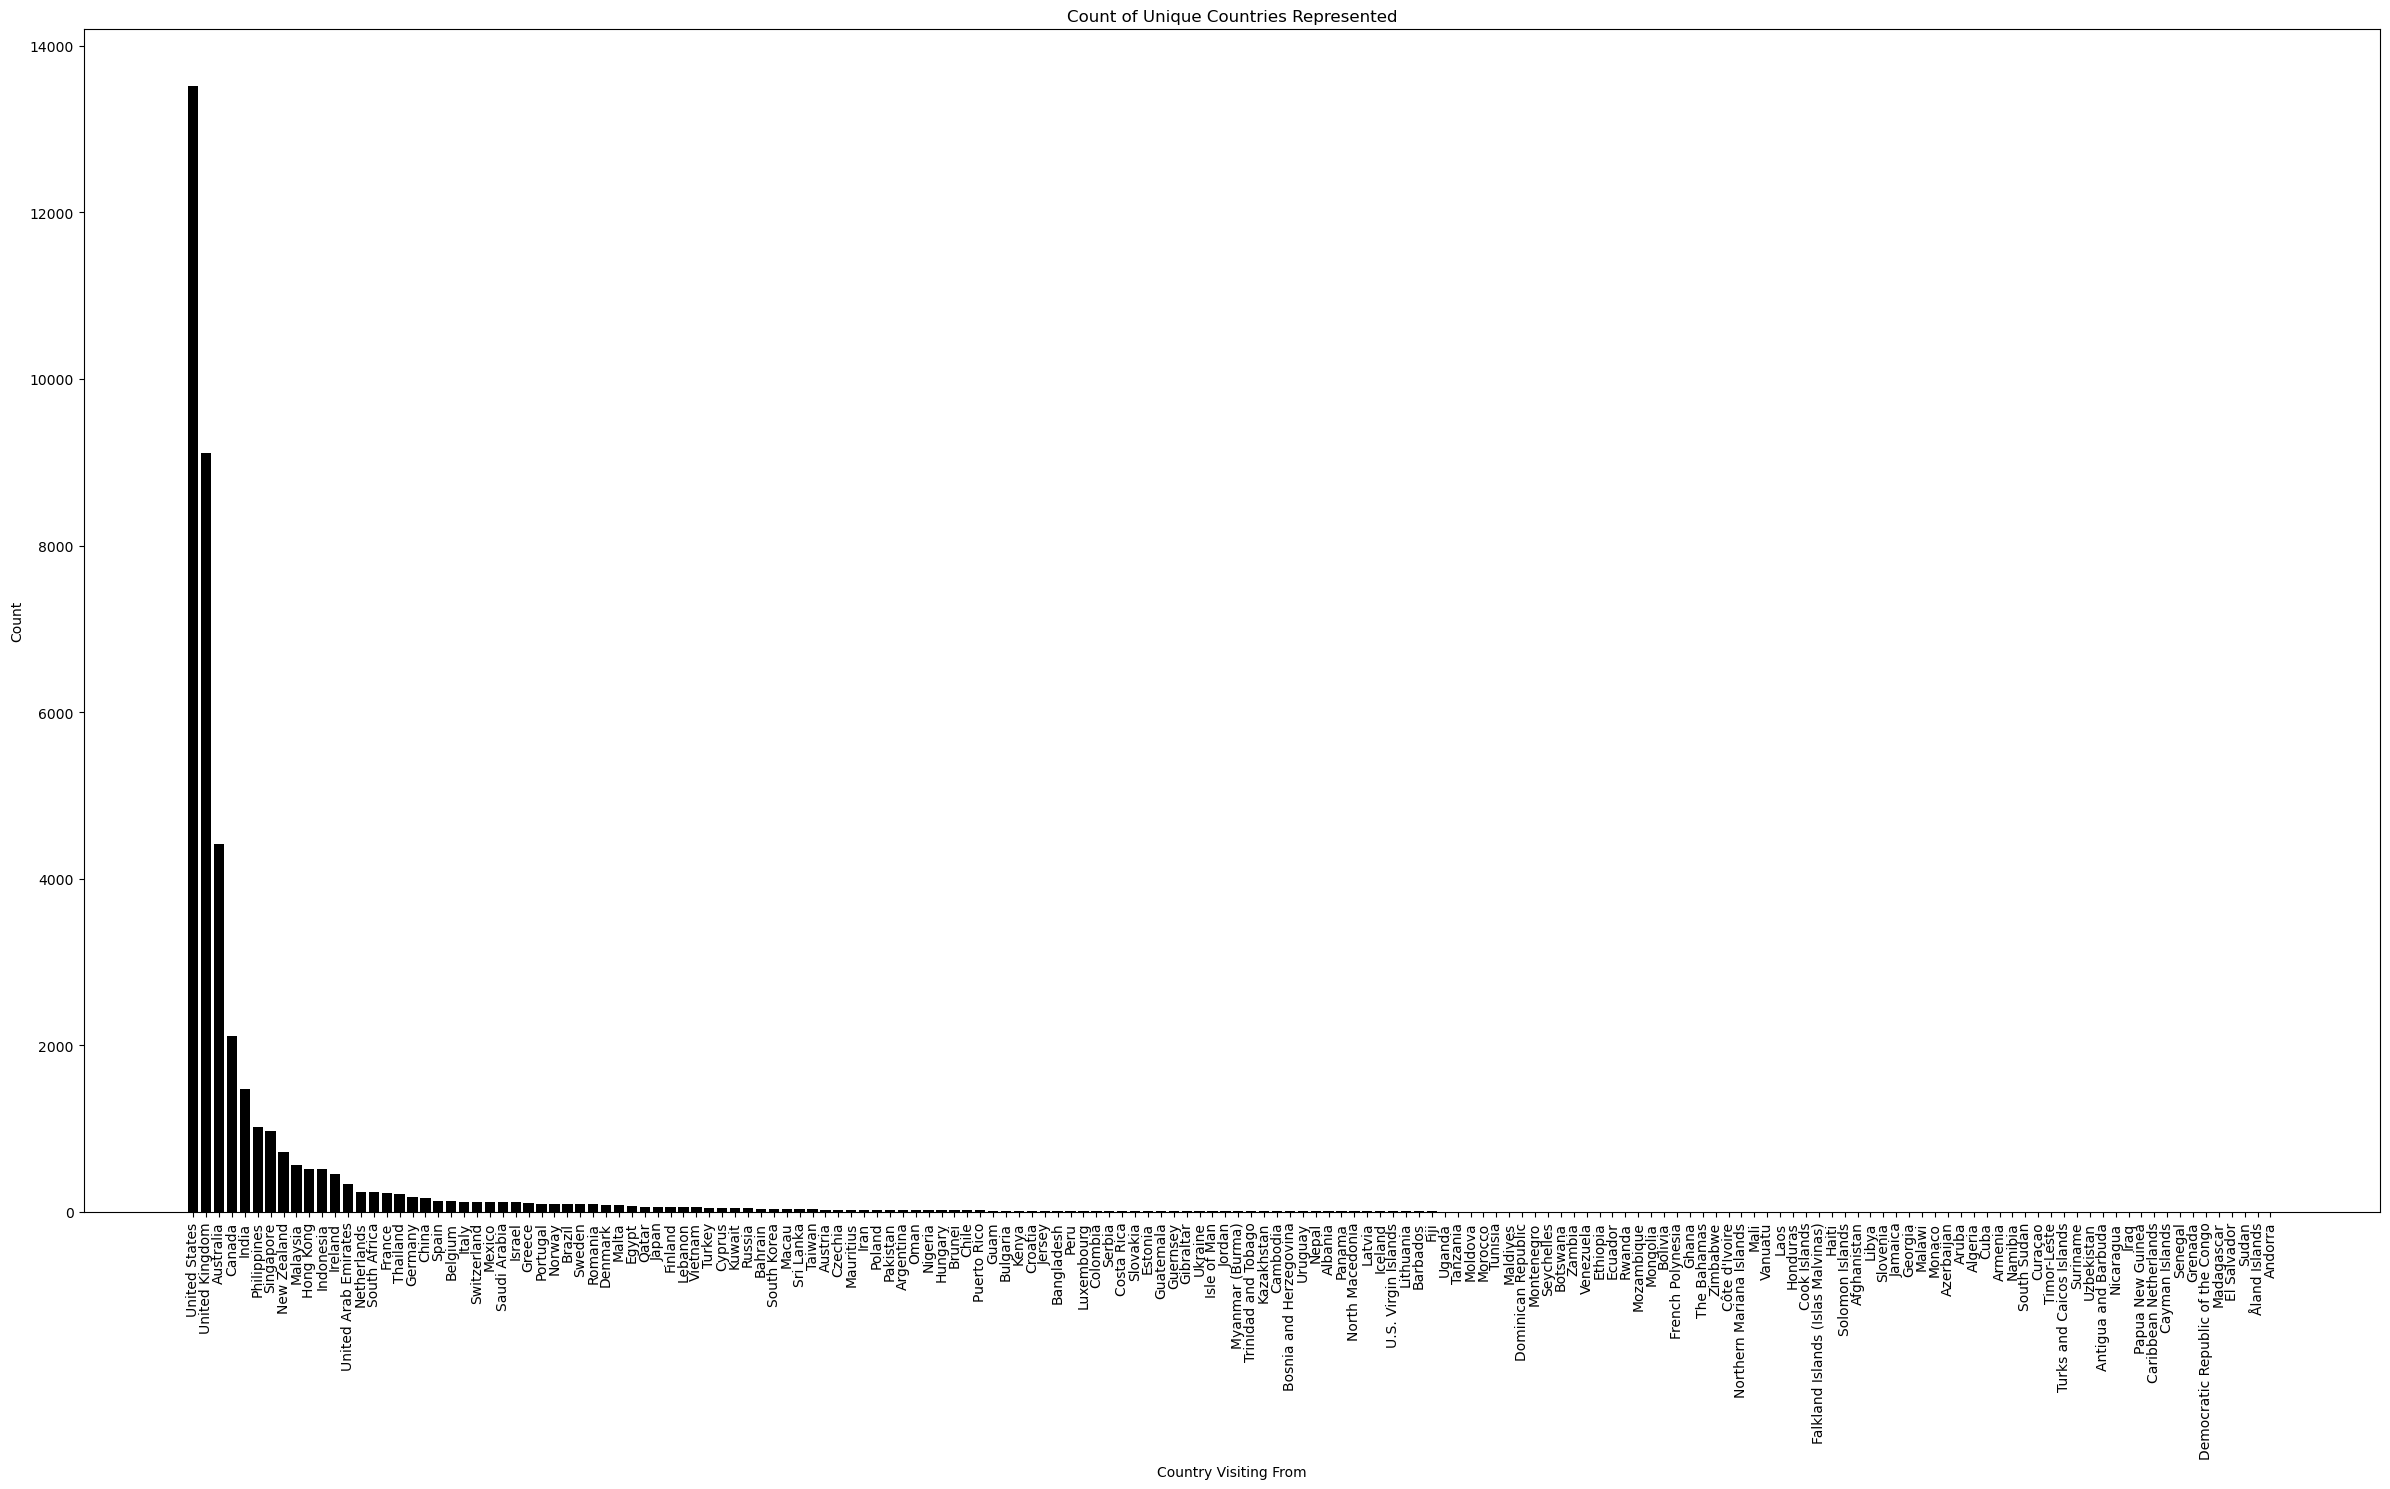

In [22]:
plt.figure(figsize=(24,15))
plt.bar(cat,freq,color="black")
plt.xlabel("Country Visiting From")
plt.ylabel("Count")
plt.title("Count of Unique Countries Represented")
plt.xticks(rotation='vertical')
plt.tight_layout()
plt.show()

There are a lot of countries to fit in this bar chart. We can see though that 3 really own a majority of the visitors (US,UK,Australia).

### Pie Chart of User Ratings

In [23]:
rate=df["Rating"].value_counts()
cat=rate.index
freq=rate.values

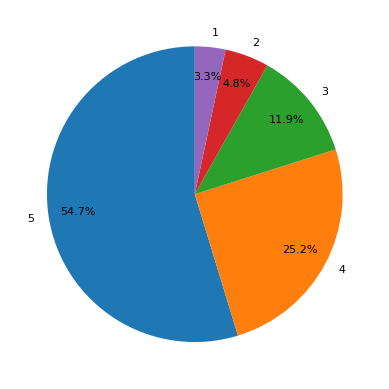

In [24]:
plt.pie(freq,labels=cat, autopct='%1.1f%%', startangle=90, pctdistance=0.8,textprops={'fontsize':8})
plt.show()

The 5 rating takes up a majority of the pie chart by a little over 50%. It will be interesting to see if sentiment analysis reflects this.

### Bar Chart for User Rating by PArk

In [25]:
rating_count=df.groupby('Branch')['Rating'].value_counts().unstack(fill_value=0)

In [26]:
rating_count.head()

Rating,1,2,3,4,5
Branch,,,,,
Disneyland_California,450,685,1552,3713,11802
Disneyland_HongKong,152,307,1297,3053,4338
Disneyland_Paris,736,937,1933,3320,5768


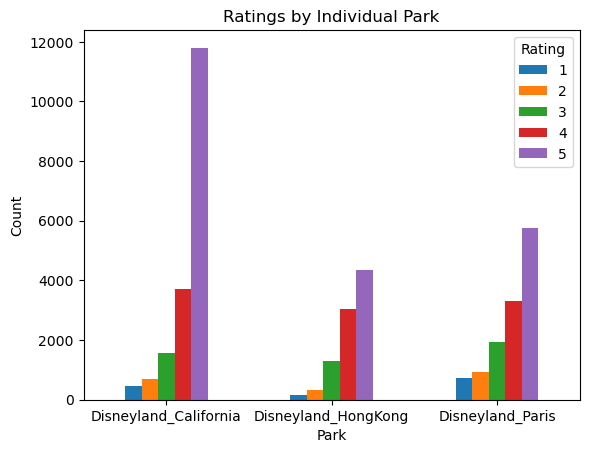

In [27]:
ax=rating_count.plot.bar(rot=0)
plt.title('Ratings by Individual Park')
plt.ylabel('Count')
plt.xlabel('Park')
plt.show()

This bar chart shows something surprising. All 3 parks seem to have similar counts for ratings 1-4. When it comes to rating 5 Disneyland_California has a very large increase compared to the other parks. This may skew somethings but we will see.

## Pie Chart for Month Visited

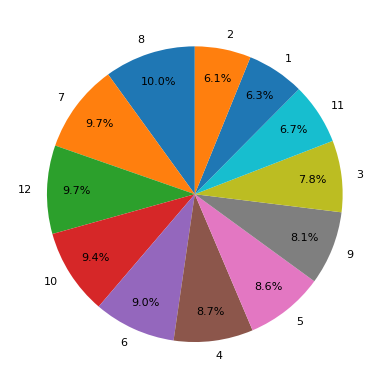

In [28]:
rate=df["Month"].value_counts()
cat=rate.index
freq=rate.values

plt.pie(freq,labels=cat, autopct='%1.1f%%', startangle=90, pctdistance=0.8,textprops={'fontsize':8})
plt.show()

I want to come back to this and rearrange the pie chart by numerica order of the label. the colder months seem to have less visits than summer and fall months. this makes sense as ppl generally tend to vacation to places where weather is nice.

## Milestone 2
### Moving Year_Month To the Front

In [29]:
col1=df.pop('Year_Month')
df.insert(0,col1.name,col1)

### Import Weather Dataset

In [30]:
df_weather=pd.read_excel("disneyland_weather.xlsx")

In [31]:
df_weather.head()

,Year_Month,Branch,High_Temp_F,Low_Temp_F,Avg_Temp_F,Sunshine_hours,Rainfall_inches,Rain_days,Pressure_mb
0,2009-1,Disneyland_Paris,39,29,34,179,1.94,6,1014
1,2010-1,Disneyland_Paris,37,28,32,107,1.31,5,1015
2,2011-1,Disneyland_Paris,43,34,38,100,2.19,6,1020
3,2012-1,Disneyland_Paris,46,37,42,132,1.47,6,1023
4,2013-1,Disneyland_Paris,41,33,37,51,2.05,11,1016


In [32]:
df_merged=pd.merge(df,df_weather,on=["Year_Month", "Branch"],how='left')
df_merged.head()

,Year_Month,Review_ID,Rating,Reviewer_Location,Review_Text,Branch,Year,Month,High_Temp_F,Low_Temp_F,Avg_Temp_F,Sunshine_hours,Rainfall_inches,Rain_days,Pressure_mb
0,2019-4,670772142,4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,2019,4,81,75,77,102,6.13,14,1012
1,2019-5,670682799,4,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,2019,5,82,76,79,69,11.40,21,1009
2,2019-4,670623270,4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,2019,4,81,75,77,102,6.13,14,1012
3,2019-4,670607911,4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,2019,4,81,75,77,102,6.13,14,1012
4,2019-4,670607296,4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,2019,4,81,75,77,102,6.13,14,1012


### Bag O Words Processing

In [33]:
from textblob import TextBlob
import unicodedata
import sys
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rwant\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rwant\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [34]:
# FOr this I'll create a function that can be applied to the whole column and creates a new column based off of polarity
def get_polarity(text):
    action=TextBlob(text)
    #Next we need to use an if/else statement to assign values to our two categories
    if action.sentiment.polarity >= 0:
        return 'positive'
    else:
        return 'negative'

df_merged['polarity']=df_merged['Review_Text'].apply(get_polarity)

def assign_polarity(text):
    if text == 'positive':
        return 1
    else:
        return 0

df_merged['polarity_num']=df_merged['polarity'].apply(assign_polarity)

punctuation=dict.fromkeys((i for i in range(sys.maxunicode)
                           if unicodedata.category(chr(i)).startswith('P')),None)

[string.translate(punctuation) for string in df_merged['Review_Text']]

#removes special characters. ^=negates the clss that follows \w=class of any word character. Includes lower case and upper case and digits. \s=any other whitespace character
df_merged['Review_Text']=df_merged['Review_Text'].str.replace(r'[^\w\s]','',regex=True)

stop_words=stopwords.words('english')
[word for word in df_merged['Review_Text'] if word not in stop_words]

porter=PorterStemmer()
def text_process(text):
    tokens=word_tokenize(text)
    tokens=[porter.stem(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df_merged['review_stem']=df_merged['Review_Text'].apply(text_process)
df_merged.head()

,Year_Month,Review_ID,Rating,Reviewer_Location,Review_Text,Branch,Year,Month,High_Temp_F,Low_Temp_F,Avg_Temp_F,Sunshine_hours,Rainfall_inches,Rain_days,Pressure_mb,polarity,polarity_num,review_stem
0,2019-4,670772142,4,Australia,If youve ever been to Disneyland anywhere youl...,Disneyland_HongKong,2019,4,81,75,77,102,6.13,14,1012,positive,1,if youv ever disneyland anywher youll find dis...
1,2019-5,670682799,4,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,2019,5,82,76,79,69,11.40,21,1009,positive,1,it sinc last time visit hk disneyland yet time...
2,2019-4,670623270,4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,2019,4,81,75,77,102,6.13,14,1012,positive,1,thank god hot humid i visit park otherwis woul...
3,2019-4,670607911,4,Australia,HK Disneyland is a great compact park Unfortun...,Disneyland_HongKong,2019,4,81,75,77,102,6.13,14,1012,positive,1,hk disneyland great compact park unfortun quit...
4,2019-4,670607296,4,United Kingdom,the location is not in the city took around 1 ...,Disneyland_HongKong,2019,4,81,75,77,102,6.13,14,1012,positive,1,locat citi took around 1 hour kowlon kid like ...


## Creating Sentiment Column

In [35]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\rwant\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [36]:
analyzer = SentimentIntensityAnalyzer()
def get_sentiment(text):
    scores = analyzer.polarity_scores(text)
    sentiment = 1 if scores['pos'] > 0 else 0
    return sentiment

In [37]:
df_merged['sentiment'] = df_merged['review_stem'].apply(get_sentiment)
df_merged

,Year_Month,Review_ID,Rating,Reviewer_Location,Review_Text,Branch,Year,Month,High_Temp_F,Low_Temp_F,Avg_Temp_F,Sunshine_hours,Rainfall_inches,Rain_days,Pressure_mb,polarity,polarity_num,review_stem,sentiment
0,2019-4,670772142,4,Australia,If youve ever been to Disneyland anywhere youl...,Disneyland_HongKong,2019,4,81,75,77,102,6.13,14,1012,positive,1,if youv ever disneyland anywher youll find dis...,1
1,2019-5,670682799,4,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,2019,5,82,76,79,69,11.40,21,1009,positive,1,it sinc last time visit hk disneyland yet time...,1
2,2019-4,670623270,4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,2019,4,81,75,77,102,6.13,14,1012,positive,1,thank god hot humid i visit park otherwis woul...,1
3,2019-4,670607911,4,Australia,HK Disneyland is a great compact park Unfortun...,Disneyland_HongKong,2019,4,81,75,77,102,6.13,14,1012,positive,1,hk disneyland great compact park unfortun quit...,1
4,2019-4,670607296,4,United Kingdom,the location is not in the city took around 1 ...,Disneyland_HongKong,2019,4,81,75,77,102,6.13,14,1012,positive,1,locat citi took around 1 hour kowlon kid like ...,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40038,2011-1,92198076,4,United Kingdom,Although our pick up was prompt the taxi drive...,Disneyland_Paris,2011,1,43,34,38,100,2.19,6,1020,positive,1,although pick prompt taxi driver wasnt sure ti...,1
40039,2011-1,92061774,4,Germany,Just returned from a 4 days family trip to Dis...,Disneyland_Paris,2011,1,43,34,38,100,2.19,6,1020,positive,1,just return 4 day famili trip disneyland two b...,1
40040,2010-12,91995748,1,United Kingdom,We spent the 20 Dec 2010 in the Disney park an...,Disneyland_Paris,2010,12,34,28,31,75,3.38,13,1014,positive,1,we spent 20 dec 2010 disney park lunchtim attr...,1
40041,2010-12,91984642,2,United Kingdom,Well I was really looking forward to this trip...,Disneyland_Paris,2010,12,34,28,31,75,3.38,13,1014,positive,1,well i realli look forward trip christma perio...,1


### Dropping the Year_Month Column and Review_ID

In [60]:
df_merged.drop(columns=['Year_Month','Review_ID'])

,Rating,Reviewer_Location,Review_Text,Branch,Year,Month,High_Temp_F,Low_Temp_F,Avg_Temp_F,Sunshine_hours,Rainfall_inches,Rain_days,Pressure_mb,polarity,polarity_num,review_stem,sentiment
0,4,Australia,If youve ever been to Disneyland anywhere youl...,Disneyland_HongKong,2019,4,81,75,77,102,6.13,14,1012,positive,1,if youv ever disneyland anywher youll find dis...,1
1,4,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,2019,5,82,76,79,69,11.40,21,1009,positive,1,it sinc last time visit hk disneyland yet time...,1
2,4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,2019,4,81,75,77,102,6.13,14,1012,positive,1,thank god hot humid i visit park otherwis woul...,1
3,4,Australia,HK Disneyland is a great compact park Unfortun...,Disneyland_HongKong,2019,4,81,75,77,102,6.13,14,1012,positive,1,hk disneyland great compact park unfortun quit...,1
4,4,United Kingdom,the location is not in the city took around 1 ...,Disneyland_HongKong,2019,4,81,75,77,102,6.13,14,1012,positive,1,locat citi took around 1 hour kowlon kid like ...,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40038,4,United Kingdom,Although our pick up was prompt the taxi drive...,Disneyland_Paris,2011,1,43,34,38,100,2.19,6,1020,positive,1,although pick prompt taxi driver wasnt sure ti...,1
40039,4,Germany,Just returned from a 4 days family trip to Dis...,Disneyland_Paris,2011,1,43,34,38,100,2.19,6,1020,positive,1,just return 4 day famili trip disneyland two b...,1
40040,1,United Kingdom,We spent the 20 Dec 2010 in the Disney park an...,Disneyland_Paris,2010,12,34,28,31,75,3.38,13,1014,positive,1,we spent 20 dec 2010 disney park lunchtim attr...,1
40041,2,United Kingdom,Well I was really looking forward to this trip...,Disneyland_Paris,2010,12,34,28,31,75,3.38,13,1014,positive,1,well i realli look forward trip christma perio...,1


### Missing Values Count

In [61]:
df_merged.isna().sum()

Year_Month           0
Review_ID            0
Rating               0
Reviewer_Location    0
Review_Text          0
Branch               0
Year                 0
Month                0
High_Temp_F          0
Low_Temp_F           0
Avg_Temp_F           0
Sunshine_hours       0
Rainfall_inches      0
Rain_days            0
Pressure_mb          0
polarity             0
polarity_num         0
review_stem          0
sentiment            0
dtype: int64

# Milestone 3 - Build Your Model
In the following section I will be showing 3 variations of a Logisitic Regression Model. The first model will be a DummyClassification model.
The second model will be a sentiment analyis Logisitic Regression model with just the basic features. The last model will be a Logisitic Regression model with average monthly weather data by year added in to see if that improves the model.

Metrics that will be used to evaluate each model will be the standard metrics for classification; accuracy, precision, recall, F1 Score, and AUC-ROC.

## Dummy Classification Model
This will have polarity_num as the target variable. It will use just "review_stem" as the feature input. From a little research it seems like StandardScaler isn't necessary for Dummy models.

In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_curve,auc
#We need the Standard Scaler because we have a barometric pressure columnd ("pressure_mn") that contains values that are much alrger than the other units of measure.
from sklearn.preprocessing import StandardScaler

In [63]:
#stemmed text
x=df_merged['review_stem']
#sentiment 1=positve 0- negative
y=df_merged['polarity_num']
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [64]:
dummy_model=DummyClassifier()
dummy_model.fit(x_train,y_train)
dummy_model.score(x_test,y_test)

0.9097265576226745

In [65]:
from sklearn.metrics import (precision_score,recall_score,f1_score)
precision=precision_score(y_test,pred_y)
recall=recall_score(y_test,pred_y)
f1score=f1_score(y_test,pred_y)
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1score}')

Precision: 0.9097265576226745
Recall: 1.0
F1 Score: 0.9527296502124878


## Logistic Regression Model for Sentiment Analysis

In [66]:
tfidf=TfidfVectorizer()
x_train_tf=tfidf.fit_transform(x_train)
x_test_tf=tfidf.transform(x_test)

model=LogisticRegression()
model.fit(x_train_tf, y_train)

LogisticRegression()

In [67]:
pred_y=model.predict(x_test_tf)

accuracy=accuracy_score(y_test,pred_y)
print(accuracy)

0.9335747284305157


In [68]:
from sklearn.metrics import confusion_matrix
matrix=confusion_matrix(y_test,pred_y)
print(matrix)

[[ 219  504]
 [  28 7258]]


In [69]:
# precision=tp/(tp+fp)
from sklearn.metrics import (precision_score,recall_score,f1_score)
precision=precision_score(y_test,pred_y)
recall=recall_score(y_test,pred_y)
f1score=f1_score(y_test,pred_y)
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1score}')

Precision: 0.9350682813707807
Recall: 0.9961570134504529
F1 Score: 0.9646464646464646


## Logistic Model with multiple input features but the same target feature

In [86]:
x=df_merged[['High_Temp_F','Low_Temp_F','Avg_Temp_F','Sunshine_hours','Rainfall_inches','Rain_days','Pressure_mb']]
#scaler=StandardScaler()
#sentiment 1=positve 0- negative
y=df_merged['polarity_num']
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [87]:
#x_train=scaler.fit_transform(x_train)
#x_test=scaler.transform(x_test)
# note for myself, applying the scaler to just 'x' before splitting the data resulted in an accuracy result exactly the same as the DummyClassifier
model.fit(x_train,y_train)

LogisticRegression()

In [88]:
pred_y=model.predict(x_test)
accuracy=accuracy_score(y_test,pred_y)
print(accuracy)

0.9097265576226745


In [89]:
matrix=confusion_matrix(y_test,pred_y)
print(matrix)

[[   0  723]
 [   0 7286]]


In [90]:
precision=precision_score(y_test,pred_y)
recall=recall_score(y_test,pred_y)
f1score=f1_score(y_test,pred_y)
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1score}')

Precision: 0.9097265576226745
Recall: 1.0
F1 Score: 0.9527296502124878
